In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import plotly.express as px
import folium
import seaborn as sns
import requests
import geopandas as gpd
import json
import re

In [69]:
!pip install plotly
!pip install geopandas
!pip install folium
!pip install kaleido


   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   -------- ------------------------------- 1/5 [orjson]
   -------- ------------------------------- 1/5 [orjson]
   ---------------- ----------------------- 2/5 [logistro]
   ---------------- ----------------------- 2/5 [logistro]
   ------------------------ -------

# 1. Load Data

1.1. Load cleaned toilets dataset

In [6]:
df = pd.read_csv ("clean_toilets_dataset.csv")

display(df.head())

,id,name,city,postalcode,lat,lon,type,accessible,payment,changing_table,water,description,municipality,source
0,1071,Egholmvej 19,Vallensbæk Strand,2665.0,55.620933,12.389692,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
1,1070,Horsbred 197,Vallensbæk,2625.0,55.650566,12.359040,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
2,1074,Højrupgårdsvej 1,Vallensbæk,2625.0,55.635456,12.367175,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet
3,1067,idræts alle 2,Vallensbæk,2625.0,55.629609,12.372302,Handicap,1,Nej,Ja,Ja,NaN,Vallensbæk,FindToilet
4,1072,Idræts alle 5,Vallensbæk,2625.0,55.632575,12.369790,Handicap,1,Nej,Nej,Ja,NaN,Vallensbæk,FindToilet


1.2. Load Population data

In [5]:
pop_df = pd.read_excel("population_density.xlsx")

pop_df.head()

,Municipality,Population,Area (km^2),Population density/(km^2),Total number of toilets,Per Capita toilets,Per square km toilets
0,Copenhagen,671714,90.9,7389.592959,406,0.060442,4.466447
1,Frederiksberg,106150,8.7,12201.149425,27,0.025436,3.103448
2,Dragør,14474,18.3,790.928962,10,0.069089,0.546448
3,Gentofte,75106,25.6,2933.828125,25,0.033286,0.976562
4,Lyngby-Taarbæk,58614,38.8,1510.670103,19,0.032415,0.489691


1.3. Load Municipality boundaries

In [7]:
# Working GeoJSON source
url = "https://raw.githubusercontent.com/magnuslarsen/geoJSON-Danish-municipalities/master/municipalities/municipalities.geojson"

# Download locally
r = requests.get(url)

print(r.status_code)

with open("municipalities.geojson", "wb") as f:
    f.write(r.content)

print("File downloaded")

# Load file
gdf = gpd.read_file("municipalities.geojson")

print(gdf.columns)

gdf.head()

200
File downloaded
Index(['lau_1', 'label_en', 'label_dk', 'iso_3166_2', 'geometry'], dtype='object')


,lau_1,label_en,label_dk,iso_3166_2,geometry
0,766,Hedensted,Hedensted,DK-82,"POLYGON Z ((9.44919 55.86046 -999, 9.4602 55.8..."
1,766,Hedensted,Hedensted,DK-82,"POLYGON Z ((10.06198 55.83301 -999, 10.06243 5..."
2,561,Esbjerg,Esbjerg,DK-83,"POLYGON Z ((8.59656 55.53506 -999, 8.60144 55...."
3,849,Jammerbugt,Jammerbugt,DK-81,"POLYGON Z ((9.78314 57.07319 -999, 9.78172 57...."
4,849,Jammerbugt,Jammerbugt,DK-81,"POLYGON Z ((9.19738 57.13868 -999, 9.20749 57...."


Create the boundries for selected municipalities

In [11]:
municipalities = [
    'Vallensbæk',
    'Dragør',
    'Hillerød',
    'Gentofte',
    'Frederiksberg',
    'Lyngby-Taarbæk',
    'Bornholm',
    'Helsingør',
    'København'
]

filtered = gdf[gdf["label_dk"].isin(municipalities)]

filtered.to_file(
    "selected_municipalities.geojson",
    driver="GeoJSON"
)

<Axes: >

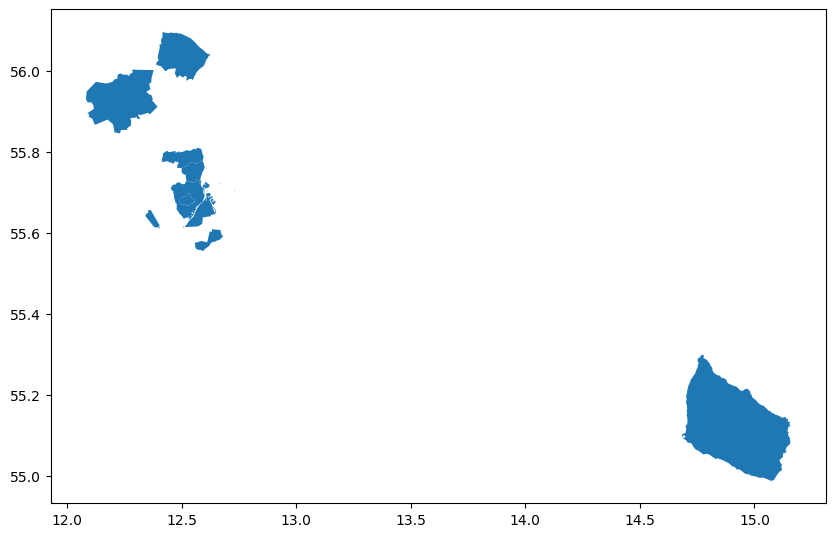

In [20]:
filtered.plot(figsize=(10, 10))

## 2. Check validity of Geo data

Since, all the other data is cleaned previously only the geo data validity is tested here

In [12]:
gdf1 = gpd.read_file("selected_municipalities.geojson")

In [13]:
from shapely.geometry import Point

# convert toilets to GeoDataFrame
geometry = [Point(xy) for xy in zip(df["lon"], df["lat"])]
toilets_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# spatial join
joined = gpd.sjoin(toilets_gdf, gdf1, how="left", predicate="within")

print(joined["index_right"].isna().sum())

15


15 Data points are outside from the boundaries that we have defined. LEt's check the municipalties that these points are belong

In [14]:
outside = joined[joined["index_right"].isna()]

outside[[
    "name", "municipality", "city", "lat", "lon", "source"
]]

,name,municipality,city,lat,lon,source
248,Havkajakvej 14,København,København S,55.648422,12.647289,FindToilet
256,Kalvebod Brygge 3C,København,København V,55.669141,12.575980,FindToilet
286,Sandkaj 37,København,Nordhavn,55.706277,12.597487,FindToilet
320,Ben Websters Vej 69,København,København SV,55.646499,12.554031,FindToilet
325,Damhusdæmningen 14,København,Vanløse,55.682449,12.468016,FindToilet
345,Langeliniekaj 63,København,København Ø,55.703656,12.600802,FindToilet
388,Kalvebod Bølge,København,København,55.667831,12.573395,OpenDataDK_TMF
400,Havnebadet Sluseholmen,København,København,55.646462,12.553980,OpenDataDK_TMF
444,Det Flydende Aktivitetshus,København,København,55.706279,12.597424,OpenDataDK_TMF
517,Strandstation 5,København,København,55.648439,12.647273,OpenDataDK_TMF


Since all the outside points are belong to Copenhagen municipalty, we have increased the boundries by 100 m to observe whether they belong to boundries

In [15]:
gdf_buffered = gdf.to_crs(epsg=25832)   # Danish projected CRS
gdf_buffered["geometry"] = gdf_buffered.geometry.buffer(100)  # 100 meters buffer
gdf_buffered = gdf_buffered.to_crs(epsg=4326)

joined_buffered = gpd.sjoin(
    toilets_gdf,
    gdf_buffered,
    how="left",
    predicate="within"
)

print("Outside after 100m buffer:", joined_buffered["index_right"].isna().sum())

Outside after 100m buffer: 0


After increasing boundries no outside points are available; which means all of these points locate near the boundries, harbour or similar places. This is just for validity check, but we do not change the boundries in the analysis

# 3. Data Analysis

## 3.1. Facility Distribution Heat Map

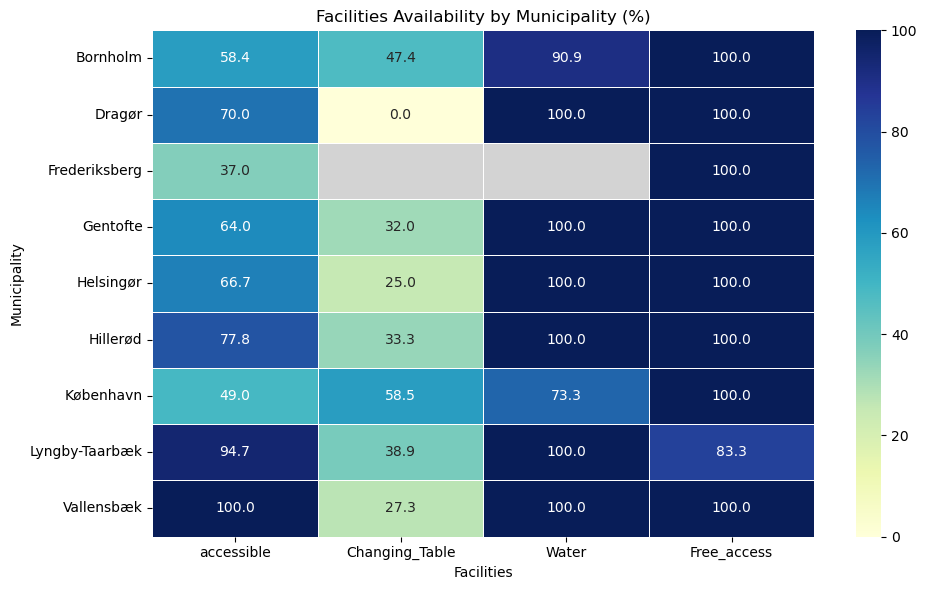

In [19]:
# Convert categorical to numeric
mapping = {
    "Ja": 1,
    "Nej": 0,
    "Unknown": None,
    "Ved ikke": None
}

df["Changing_Table"] = df["changing_table"].map(mapping)
df["Water"] = df["water"].map(mapping)

# Payment: treat "Nej" (No payment) as free
df["Free_access"] = df["payment"].map({
    "Nej": 1,
    "Ja": 0,
    "Unknown": None,
    "Ved ikke": None
})
heatmap_data = df.groupby("municipality").agg({
    "accessible": "mean",
    "Changing_Table": "mean",
    "Water": "mean",
    "Free_access": "mean"
})
heatmap_data = heatmap_data * 100
heatmap_data = heatmap_data.round(1)

# Create a copy of colormap
cmap = sns.color_palette("YlGnBu", as_cmap=True)

# Set color for NaN values (light gray)
cmap.set_bad(color="lightgrey")

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap=cmap,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Facilities Availability by Municipality (%)")
plt.xlabel("Facilities")
plt.ylabel("Municipality")

plt.tight_layout()
plt.savefig("facility_distribution_heatmap")
plt.show()

## 3.2 Toilets Distribution map with accessibility

In [21]:

# Clean data
map_df = df.dropna(subset=["lat", "lon"]).copy()

# Convert accessibility safely
map_df["accessible"] = (
    pd.to_numeric(map_df["accessible"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# CREATE MAP

overview_map = folium.Map(
    location=[55.68, 12.57],
    zoom_start=9,
    tiles="OpenStreetMap"
)

# ADD TOILET POINTS

for _, row in map_df.iterrows():

    color = "green" if row["accessible"] == 1 else "red"

    popup_text = f"""
    <b>{row.get('name', 'Unknown')}</b><br>
    Municipality: {row.get('municipality', 'Unknown')}<br>
    City: {row.get('city', 'Unknown')}<br>
    Type: {row.get('type', 'Unknown')}
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        weight=1,
        popup=popup_text
    ).add_to(overview_map)

# DISPLAY

overview_map

## 3.3 Toilet Distribution Movie Map

According to the available data, municipalties are scattered around vast region. So proper distribution cannot be observed within the municipalty. Therefore, we zoom each municipalty by indicating their boundaries fro proper understanding.

In [67]:
from branca.element import MacroElement
from jinja2 import Template


# CLEAN TOILET DATA

map_df = df.dropna(subset=["lat", "lon", "municipality"]).copy()
map_df["municipality"] = map_df["municipality"].str.strip()

map_df["accessible"] = (
    pd.to_numeric(map_df["accessible"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# LOAD MUNICIPALITY BOUNDARIES
muni_gdf = gpd.read_file("selected_municipalities.geojson")
muni_gdf = muni_gdf.to_crs(epsg=4326)
muni_gdf["label_dk"] = muni_gdf["label_dk"].str.strip()

# Fix invalid geometries
muni_gdf["geometry"] = muni_gdf.geometry.buffer(0)

# MUNICIPALITIES TO ANIMATE
municipalities = [
    "Vallensbæk",
    "Dragør",
    "Hillerød",
    "Gentofte",
    "Frederiksberg",
    "Lyngby-Taarbæk",
    "Helsingør",
    "København",
    "Bornholm"
]

map_df = map_df[map_df["municipality"].isin(municipalities)].copy()
muni_gdf = muni_gdf[muni_gdf["label_dk"].isin(municipalities)].copy()

available_munis = sorted(
    set(map_df["municipality"].unique()) &
    set(muni_gdf["label_dk"].unique())
)

municipalities = [m for m in municipalities if m in available_munis]

print("Municipalities used:", municipalities)

# CONVERT DATA TO JSON
def safe_str(x):
    if pd.isna(x):
        return "Unknown"
    return str(x)

records = []

for _, row in map_df.iterrows():
    records.append({
        "municipality": safe_str(row["municipality"]),
        "lat": float(row["lat"]),
        "lon": float(row["lon"]),
        "name": safe_str(row.get("name")),
        "city": safe_str(row.get("city")),
        "type": safe_str(row.get("type")),
        "accessible": int(row["accessible"])
    })

municipality_geojson = json.loads(muni_gdf.to_json())

# CREATE MAP
m = folium.Map(
    location=[55.75, 12.45],
    zoom_start=9,
    tiles="CartoDB positron"
)


# ANIMATION CLASS
class MunicipalityAnimation(MacroElement):

    def __init__(self, records, municipalities, municipality_geojson):
        super().__init__()

        self._name = "MunicipalityAnimation"
        self.records = json.dumps(records)
        self.municipalities = json.dumps(municipalities)
        self.municipality_geojson = json.dumps(municipality_geojson)

        self._template = Template("""
        {% macro html(this, kwargs) %}

        <div id="municipality-box" style="
            position: fixed;
            top: 100px;
            left: 20px;
            width: 220px;
            background-color: white;
            border: 2px solid #555;
            z-index: 9999;
            font-size: 15px;
            padding: 12px;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.25);
        ">

            <b style="font-size:18px;">Municipality</b><br>
            <span id="municipality-name" style="font-size:17px;">Loading...</span>

            <br><br>

            Total toilets: <span id="total-count">0</span><br>
            <span style="color:blue;">●</span> Accessible:
            <span id="accessible-count">0</span><br>
            <span style="color:red;">●</span> Not accessible:
            <span id="not-accessible-count">0</span>

            <br><br>

            <button id="prev-btn">Previous</button>
            <button id="play-btn">Pause</button>
            <button id="next-btn">Next</button>

            <br><br>

            <small>
                <span style="color:#003f8c;">━</span> Current municipality<br>
                <span style="color:#999;">━</span> Other municipalities
            </small>

        </div>

        {% endmacro %}

        {% macro script(this, kwargs) %}

        var toiletData = {{ this.records }};
        var municipalities = {{ this.municipalities }};
        var geojsonData = {{ this.municipality_geojson }};
        var map = {{ this._parent.get_name() }};

        var currentIndex = 0;
        var animationSpeed = 7000;
        var animationTimer = null;
        var isPlaying = true;

        var activeMarkers = [];
        var activePolygon = null;
        var backgroundPolygons = null;

        // Change to false if you want to hide other municipality boundaries completely
        var showOtherBoundaries = true;

        function clearLayers() {
            activeMarkers.forEach(function(marker) {
                map.removeLayer(marker);
            });
            activeMarkers = [];

            if (activePolygon) {
                map.removeLayer(activePolygon);
                activePolygon = null;
            }

            if (backgroundPolygons) {
                map.removeLayer(backgroundPolygons);
                backgroundPolygons = null;
            }
        }

        function showMunicipality(index) {
            clearLayers();

            var currentMuni = municipalities[index];
            document.getElementById("municipality-name").innerHTML = currentMuni;

            var total = 0;
            var accessible = 0;
            var notAccessible = 0;

            var combinedBounds = L.latLngBounds([]);

            // ---------------------------------------------------
            // LIGHT BACKGROUND BOUNDARIES
            // ---------------------------------------------------

            if (showOtherBoundaries) {
                backgroundPolygons = L.geoJSON(geojsonData, {
                    filter: function(feature) {
                        return feature.properties.label_dk !== currentMuni;
                    },
                    style: {
                        color: "#999999",
                        weight: 1,
                        fillColor: "#dddddd",
                        fillOpacity: 0.05,
                        opacity: 0.35
                    },
                    interactive: false
                }).addTo(map);
            }

            // ---------------------------------------------------
            // ACTIVE MUNICIPALITY BOUNDARY
            // ---------------------------------------------------

            activePolygon = L.geoJSON(geojsonData, {
                filter: function(feature) {
                    return feature.properties.label_dk === currentMuni;
                },
                style: {
                    color: "#003f8c",
                    weight: 4,
                    fillColor: "#4a90e2",
                    fillOpacity: 0.12,
                    opacity: 1
                }
            }).addTo(map);

            if (activePolygon.getBounds().isValid()) {
                combinedBounds.extend(activePolygon.getBounds());
            }

            // ---------------------------------------------------
            // TOILET POINTS
            // ---------------------------------------------------

            toiletData.forEach(function(row) {
                if (row.municipality === currentMuni) {

                    total += 1;

                    var color = row.accessible === 1 ? "blue" : "red";
                    var accessText = row.accessible === 1 ? "Accessible" : "Not accessible";

                    if (row.accessible === 1) {
                        accessible += 1;
                    } else {
                        notAccessible += 1;
                    }

                    var popupText =
                        "<b>" + row.name + "</b><br>" +
                        "Municipality: " + row.municipality + "<br>" +
                        "City: " + row.city + "<br>" +
                        "Type: " + row.type + "<br>" +
                        "Accessibility: " + accessText;

                    var marker = L.circleMarker(
                        [row.lat, row.lon],
                        {
                            radius: 4,
                            color: color,
                            fillColor: color,
                            fillOpacity: 0.75,
                            opacity: 0.9,
                            weight: 1
                        }
                    ).bindPopup(popupText);

                    marker.addTo(map);
                    activeMarkers.push(marker);

                    combinedBounds.extend([row.lat, row.lon]);
                }
            });

            document.getElementById("total-count").innerHTML = total;
            document.getElementById("accessible-count").innerHTML = accessible;
            document.getElementById("not-accessible-count").innerHTML = notAccessible;

            if (combinedBounds.isValid()) {
                map.fitBounds(combinedBounds, {
                    padding: [90, 90],
                    maxZoom: 12
                });
            }

            if (currentMuni === "København") {
                setTimeout(function() {
                    if (map.getZoom() > 11) {
                        map.setZoom(11);
                    }
                }, 300);
            }

            if (
                currentMuni === "Vallensbæk" ||
                currentMuni === "Dragør" ||
                currentMuni === "Frederiksberg"
            ) {
                setTimeout(function() {
                    if (map.getZoom() > 13) {
                        map.setZoom(13);
                    }
                }, 300);
            }

            if (currentMuni === "Bornholm") {
                setTimeout(function() {
                    if (map.getZoom() > 10) {
                        map.setZoom(10);
                    }
                }, 300);
            }
        }

        function nextMunicipality() {
            currentIndex = (currentIndex + 1) % municipalities.length;
            showMunicipality(currentIndex);
        }

        function prevMunicipality() {
            currentIndex = (currentIndex - 1 + municipalities.length) % municipalities.length;
            showMunicipality(currentIndex);
        }

        function startAnimation() {
            animationTimer = setInterval(nextMunicipality, animationSpeed);
            isPlaying = true;
            document.getElementById("play-btn").innerHTML = "Pause";
        }

        function stopAnimation() {
            clearInterval(animationTimer);
            animationTimer = null;
            isPlaying = false;
            document.getElementById("play-btn").innerHTML = "Play";
        }

        document.getElementById("play-btn").onclick = function() {
            if (isPlaying) {
                stopAnimation();
            } else {
                startAnimation();
            }
        };

        document.getElementById("next-btn").onclick = function() {
            stopAnimation();
            nextMunicipality();
        };

        document.getElementById("prev-btn").onclick = function() {
            stopAnimation();
            prevMunicipality();
        };

        showMunicipality(currentIndex);
        startAnimation();

        {% endmacro %}
        """)


# ADD TO MAP
animation = MunicipalityAnimation(
    records,
    municipalities,
    municipality_geojson
)

m.add_child(animation)

# Create folder to save maps
import os
os.makedirs("maps", exist_ok=True)

# Save map
m.save("maps/toilet_distribution_map.html")

m

Municipalities used: ['Vallensbæk', 'Dragør', 'Hillerød', 'Gentofte', 'Frederiksberg', 'Lyngby-Taarbæk', 'Helsingør', 'København', 'Bornholm']


The main reason for selecting movie map to show the toilets distribution is the scattered behaviour of municipalities that we have selected. Since some of them are not neighbour municipalities, maps like choropleth are meaning less when visualize the distribution of toilets. Furthermore, since each municipalty is different in the size of area, we wanted to isolate and zoom out to show the proper distribution 

## 3.4 Opening hours heatmap

Total toilets: 620
Toilets with detected opening hours: 157


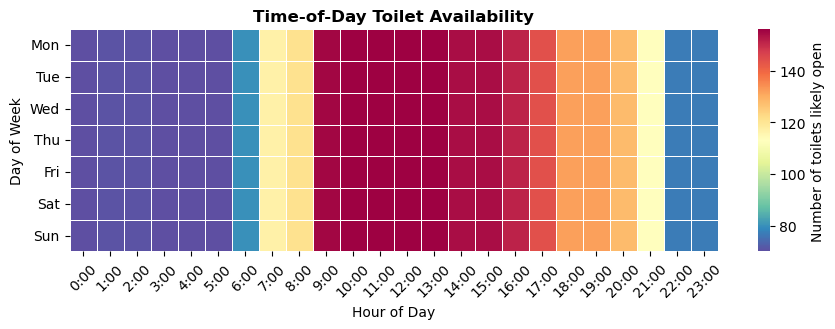

In [84]:
# COPY DATA

hours_df = df.copy()

# Use description column because opening hours are inside text
hours_df["description"] = hours_df["description"].fillna("").astype(str)

# FUNCTION: DETECT OPENING HOURS

def extract_open_hours(text):
    text = text.lower()

    # 24-hour toilets
    if (
        "døgnåbent" in text
        or "24/7" in text
        or "hele døgnet" in text
        or "doegnaabent: ja" in text
    ):
        return list(range(24))

    # Match time ranges like 7-22, 07:00-22:00, 9.00 - 21.00
    patterns = re.findall(
        r"(\d{1,2})(?:[:.]\d{2})?\s*[–\-]\s*(\d{1,2})(?:[:.]\d{2})?",
        text
    )

    open_hours = []

    for start, end in patterns:
        start = int(start)
        end = int(end)

        if 0 <= start <= 23 and 0 <= end <= 24:
            if start < end:
                open_hours.extend(range(start, end))
            else:
                # overnight case, e.g. 22-06
                open_hours.extend(list(range(start, 24)) + list(range(0, end)))

    return sorted(set(open_hours))


# APPLY FUNCTION

hours_df["open_hours"] = hours_df["description"].apply(extract_open_hours)

# Keep only rows where some opening hour could be detected
hours_df_valid = hours_df[hours_df["open_hours"].apply(len) > 0].copy()

print("Total toilets:", len(hours_df))
print("Toilets with detected opening hours:", len(hours_df_valid))


# CREATE DAY-HOUR MATRIX

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hours = list(range(24))

heat_data = pd.DataFrame(0, index=days, columns=hours)

# Assumption: if opening hours are detected, apply to all days
# unless your text is parsed in more detail later
for _, row in hours_df_valid.iterrows():
    for h in row["open_hours"]:
        for d in days:
            heat_data.loc[d, h] += 1


# PLOT HEATMAP

plt.figure(figsize=(9, 3.4))

sns.heatmap(
    heat_data,
    cmap="Spectral_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of toilets likely open"}
)

plt.title("Time-of-Day Toilet Availability", fontsize=12, weight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.xticks(
    ticks=np.arange(24) + 0.5,
    labels=[f"{h}:00" for h in range(24)],
    rotation=45
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("opening hours heatmap")
plt.show()

Opening hours are not directly provided in the dataset. Therefore, we extracted them through the description. But most of the descriptions do not include opening hours details. Out of 620 data points, only 157 points provide opening hours details. This can be not 100% accurate due to extraction data from the teaxt and slightly misleading. However, averall it shows reasonable distribution. The reason for selecting this map is to clear visualization of opening hours distribution, this is very attractive way and easy to understand.

## 3.5 Interactive map with facility selection

In [63]:
from branca.element import MacroElement
from jinja2 import Template


# DATA

facility_df = df.dropna(subset=["lat", "lon", "municipality"]).copy()
facility_df["municipality"] = facility_df["municipality"].astype(str).str.strip()

facility_df["accessible"] = (
    pd.to_numeric(facility_df["accessible"], errors="coerce")
    .fillna(0)
    .astype(int)
)


# LOAD MUNICIPALITY BOUNDARIES
muni_gdf = gpd.read_file("selected_municipalities.geojson")
muni_gdf = muni_gdf.to_crs(epsg=4326)
muni_gdf["label_dk"] = muni_gdf["label_dk"].astype(str).str.strip()
muni_gdf["geometry"] = muni_gdf.geometry.buffer(0)

# Keep only municipalities that exist in toilet data
available_munis = sorted(set(facility_df["municipality"]) & set(muni_gdf["label_dk"]))
facility_df = facility_df[facility_df["municipality"].isin(available_munis)].copy()
muni_gdf = muni_gdf[muni_gdf["label_dk"].isin(available_munis)].copy()


# SAFE STRING FUNCTION

def safe_str(x):
    if pd.isna(x):
        return "Unknown"
    return str(x)


# RECORDS FOR JAVASCRIPT
records = []

for _, row in facility_df.iterrows():
    records.append({
        "municipality": safe_str(row.get("municipality")),
        "lat": float(row["lat"]),
        "lon": float(row["lon"]),
        "name": safe_str(row.get("name")),
        "city": safe_str(row.get("city")),
        "type": safe_str(row.get("type")),
        "accessible": int(row.get("accessible", 0)),
        "payment": safe_str(row.get("payment")),
        "changing_table": safe_str(row.get("changing_table")),
        "water": safe_str(row.get("water")),
        "description": safe_str(row.get("description"))
    })

records_json = json.dumps(records)
municipality_geojson = json.dumps(json.loads(muni_gdf.to_json()))


# CREATE BASE MAP
m = folium.Map(
    location=[facility_df["lat"].mean(), facility_df["lon"].mean()+1.0],
    zoom_start=8,
    tiles="OpenStreetMap"
)


# CUSTOM INTERACTIVE FILTER WITH BOUNDARIES

class FacilityFilterMap(MacroElement):

    def __init__(self, records_json, municipality_geojson):
        super().__init__()
        self._name = "FacilityFilterMap"
        self.records_json = records_json
        self.municipality_geojson = municipality_geojson

        self._template = Template("""
        {% macro html(this, kwargs) %}

        <div id="filter-panel" style="
            position: fixed;
            top: 20px;
            right: 20px;
            width: 230px;
            background-color: white;
            border: 2px solid #555;
            z-index: 9999;
            font-size: 12px;
            padding: 10px;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.25);
        ">

            <b style="font-size:14px;">Find toilets by facilities</b>

            <br><br>

            <label>
                <input type="checkbox" id="filter-accessible">
                Accessible toilet
            </label><br>

            <label>
                <input type="checkbox" id="filter-changing">
                Changing table
            </label><br>

            <label>
                <input type="checkbox" id="filter-water">
                Water available
            </label><br>

            <label>
                <input type="checkbox" id="filter-free">
                Free to use
            </label><br>

            <br>

            <label><b>Municipality</b></label><br>
            <select
                id="municipality-select"
                style="
                    width:100%;
                    margin-top:4px;
                    padding:3px;
                    font-size:12px;
                "
            >
                <option value="All">All municipalities</option>
            </select>

            <br><br>

            Matching toilets:
            <b><span id="match-count">0</span></b>

            <br><br>

            <img src="https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-blue.png"
                 width="14"> Accessible<br>

            <img src="https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-red.png"
                 width="14"> Not accessible<br>
            <span style="color:#003f8c;">━</span> Selected boundary<br>
            <span style="color:#999;">━</span> Other boundaries

        </div>

        {% endmacro %}

        {% macro script(this, kwargs) %}

        var toiletData = {{ this.records_json }};
        var geojsonData = {{ this.municipality_geojson }};
        var map = {{ this._parent.get_name() }};

        var activeMarkers = [];
        var activeBoundary = null;
        var backgroundBoundaries = null;

        // ---------------------------------------------------
        // ADD MUNICIPALITIES TO DROPDOWN
        // ---------------------------------------------------

        var municipalities = [...new Set(toiletData.map(d => d.municipality))].sort();
        var select = document.getElementById("municipality-select");

        municipalities.forEach(function(muni) {
            var option = document.createElement("option");
            option.value = muni;
            option.text = muni;
            select.appendChild(option);
        });

        // ---------------------------------------------------
        // CLEAN YES/NO VALUES
        // ---------------------------------------------------

        function isYes(value) {
            if (!value) return false;
            value = value.toString().toLowerCase().trim();
            return value === "ja" || value === "yes" || value === "1" || value === "true";
        }

        function isNo(value) {
            if (!value) return false;
            value = value.toString().toLowerCase().trim();
            return value === "nej" || value === "no" || value === "0" || value === "false";
        }

        // ---------------------------------------------------
        // CLEAR LAYERS
        // ---------------------------------------------------

        function clearLayers() {
            activeMarkers.forEach(function(marker) {
                map.removeLayer(marker);
            });
            activeMarkers = [];

            if (activeBoundary) {
                map.removeLayer(activeBoundary);
                activeBoundary = null;
            }

            if (backgroundBoundaries) {
                map.removeLayer(backgroundBoundaries);
                backgroundBoundaries = null;
            }
        }

        // ---------------------------------------------------
        // ADD BOUNDARIES
        // ---------------------------------------------------

        function addBoundaries(selectedMuni, bounds) {

            if (selectedMuni === "All") {
                backgroundBoundaries = L.geoJSON(geojsonData, {
                    style: {
                        color: "#003f8c",
                        weight: 2,
                        fillColor: "#4a90e2",
                        fillOpacity: 0.06,
                        opacity: 0.85
                    },
                    tooltip: function(layer) {
                        return layer.feature.properties.label_dk;
                    }
                }).addTo(map);

                if (backgroundBoundaries.getBounds().isValid()) {
                    bounds.extend(backgroundBoundaries.getBounds());
                }

            } else {

                backgroundBoundaries = L.geoJSON(geojsonData, {
                    filter: function(feature) {
                        return feature.properties.label_dk !== selectedMuni;
                    },
                    style: {
                        color: "#999999",
                        weight: 1,
                        fillColor: "#dddddd",
                        fillOpacity: 0.04,
                        opacity: 0.30
                    },
                    interactive: false
                }).addTo(map);

                activeBoundary = L.geoJSON(geojsonData, {
                    filter: function(feature) {
                        return feature.properties.label_dk === selectedMuni;
                    },
                    style: {
                        color: "#003f8c",
                        weight: 4,
                        fillColor: "#4a90e2",
                        fillOpacity: 0.12,
                        opacity: 1
                    }
                }).addTo(map);

                if (activeBoundary.getBounds().isValid()) {
                    bounds.extend(activeBoundary.getBounds());
                }
            }
        }

        // ---------------------------------------------------
        // UPDATE MAP
        // ---------------------------------------------------

        function updateMap() {

            clearLayers();

            var requireAccessible = document.getElementById("filter-accessible").checked;
            var requireChanging = document.getElementById("filter-changing").checked;
            var requireWater = document.getElementById("filter-water").checked;
            var requireFree = document.getElementById("filter-free").checked;
            var selectedMuni = document.getElementById("municipality-select").value;

            var bounds = L.latLngBounds([]);

            addBoundaries(selectedMuni, bounds);

            var filtered = toiletData.filter(function(row) {

                if (selectedMuni !== "All" && row.municipality !== selectedMuni) {
                    return false;
                }

                if (requireAccessible && row.accessible !== 1) {
                    return false;
                }

                if (requireChanging && !isYes(row.changing_table)) {
                    return false;
                }

                if (requireWater && !isYes(row.water)) {
                    return false;
                }

                if (requireFree && !isNo(row.payment)) {
                    return false;
                }

                return true;
            });

            filtered.forEach(function(row) {

                var iconColor = row.accessible === 1 ? "blue" : "red";
                var accessText = row.accessible === 1 ? "Accessible" : "Not accessible";

                var popupText =
                    "<b>" + row.name + "</b><br>" +
                    "Municipality: " + row.municipality + "<br>" +
                    "City: " + row.city + "<br>" +
                    "Type: " + row.type + "<br>" +
                    "Accessibility: " + accessText + "<br>" +
                    "Changing table: " + row.changing_table + "<br>" +
                    "Water: " + row.water + "<br>" +
                    "Payment: " + row.payment;

                var marker = L.marker(
                    [row.lat, row.lon],
                    {
                        icon: L.icon({
                            iconUrl:
                                row.accessible === 1
                                ? "https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-blue.png"
                                : "https://raw.githubusercontent.com/pointhi/leaflet-color-markers/master/img/marker-icon-red.png",

                            shadowUrl:
                                "https://cdnjs.cloudflare.com/ajax/libs/leaflet/0.7.7/images/marker-shadow.png",

                            iconSize: [18, 30],
                            iconAnchor: [9, 30],
                            popupAnchor: [1, -28],
                            shadowSize: [30, 30]
                        })
                    }
                ).bindPopup(popupText);

                marker.addTo(map);
                activeMarkers.push(marker);
                bounds.extend([row.lat, row.lon]);
            });

            document.getElementById("match-count").innerHTML = filtered.length;

            if (bounds.isValid()) {
                map.fitBounds(bounds, {
                    paddingTopLeft: [50, 50],
                    paddingBottomRight: [250, 80],
                    maxZoom: selectedMuni === "All" ? 9 : 13
                });
            }

            if (selectedMuni === "København") {
                setTimeout(function() {
                    if (map.getZoom() > 11) {
                        map.setZoom(11);
                    }
                }, 300);
            }

            if (
                selectedMuni === "Vallensbæk" ||
                selectedMuni === "Dragør" ||
                selectedMuni === "Frederiksberg"
            ) {
                setTimeout(function() {
                    if (map.getZoom() > 13) {
                        map.setZoom(13);
                    }
                }, 300);
            }

            if (selectedMuni === "Bornholm") {
                setTimeout(function() {
                    if (map.getZoom() > 10) {
                        map.setZoom(10);
                    }
                }, 300);
            }
        }

        // ---------------------------------------------------
        // EVENT LISTENERS
        // ---------------------------------------------------

        document.getElementById("filter-accessible").addEventListener("change", updateMap);
        document.getElementById("filter-changing").addEventListener("change", updateMap);
        document.getElementById("filter-water").addEventListener("change", updateMap);
        document.getElementById("filter-free").addEventListener("change", updateMap);
        document.getElementById("municipality-select").addEventListener("change", updateMap);

        updateMap();

        {% endmacro %}
        """)

facility_filter = FacilityFilterMap(records_json, municipality_geojson)
m.add_child(facility_filter)

import os
os.makedirs("maps", exist_ok=True)

m.save("maps/facility_filter_map.html")

m

We use this interactive plot because person would like to observe the distribution of toilets based on their needs or locations. Furthermore, since these icons are in general use they are aware of this map provide location details and reduce confusion when it becomes interactive

## 3.6 Scatter plot of Per capita toilet distribution

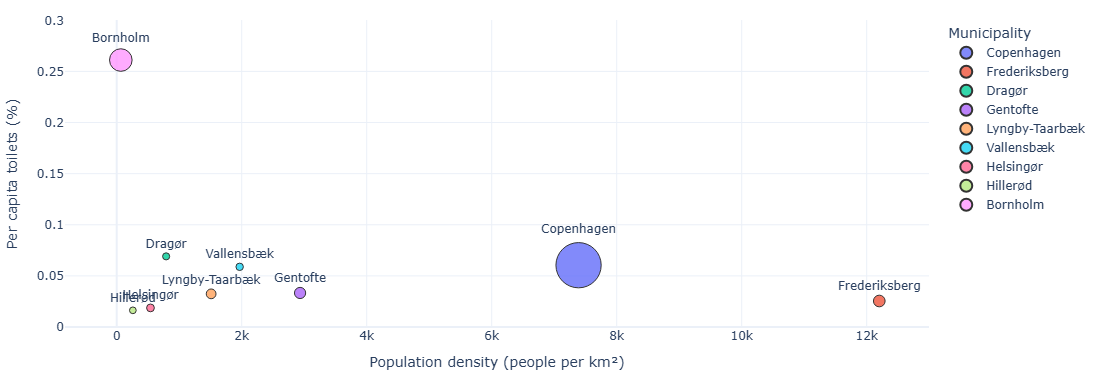

In [80]:
pop_df["Municipality"] = pop_df["Municipality"].str.strip()
gdf1["label_dk"] = gdf1["label_dk"].str.strip()

pop_df.columns = pop_df.columns.str.strip()

# Rename messy columns
pop_df = pop_df.rename(columns={
    "Municipalty": "Municipality",
    "Population density/(km^2)": "Population density",
    "Total number of toilets": "Total toilets",
    "Per Capita toilets": "Per capita toilets",
    "Per square km toilets": "Per square km toilets"
})

# Clean values
pop_df["Municipality"] = pop_df["Municipality"].astype(str).str.strip()

pop_df["Per capita toilets"] = (
    pop_df["Per capita toilets"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

pop_df["Population density"] = pd.to_numeric(pop_df["Population density"], errors="coerce")
pop_df["Total toilets"] = pd.to_numeric(pop_df["Total toilets"], errors="coerce")

# Scatter plot
fig = px.scatter(
    pop_df,
    x="Population density",
    y="Per capita toilets",
    size="Total toilets",
    color="Municipality",
    hover_name="Municipality",
    text="Municipality",
    size_max=32,
    #title="Population Density vs Per Capita Toilet Access",
    labels={
        "Population density": "Population density (people per km²)",
        "Per capita toilets": "Per capita toilets (%)",
        "Total toilets": "Total toilets"
    },
    template="plotly_white"
)

fig.update_traces(
    textposition="top center",
    marker=dict(
        opacity=0.8,
        line=dict(width=1, color="black")
    )
)

fig.update_layout(

    height=380,

    margin=dict(
        l=40,
        r=40,
        t=20,
        b=40
    ),

    legend_title_text="Municipality",

    yaxis=dict(
        title="Per capita toilets (%)",
        automargin=True,
        range=[
            0,
            pop_df["Per capita toilets"].max() * 1.15
        ]
    )
)

import os

# Create folder 
os.makedirs("maps", exist_ok=True)

# Save interactive HTML
fig.write_html("maps/scatter_plot.html")
#fig.write_image("plots/scatter_plot.png")
fig.show()

The reason of selecting this visula is to present clear difference of some municipalties in a interesting way and beacause of the ability of contain more data in a 2D visual